In [20]:
# ------------------------------
# IMPORTING LIBRARIES
# ------------------------------
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ------------------------------
# Step 0: Create fictive data
# ------------------------------
np.random.seed(144)
plastic_type = np.random.choice(
    ['Polycarbonate', 'ABS', 'Polypropylene'],
    size=1000,
    p=[0.5, 0.3, 0.2]
)

np.random.seed(145); melt_flow_index = np.random.uniform(5, 30, 1000)
np.random.seed(146); moisture_content = np.random.uniform(0.001, 0.1, 1000)
np.random.seed(147); injection_temperature = np.random.normal(250, 25, 1000)
np.random.seed(148); injection_pressure = np.random.uniform(10000, 20000, 1000)
np.random.seed(149); mold_temperature = np.random.normal(80, 20, 1000)
np.random.seed(150); cooling_time = np.random.normal(25, 5, 1000)
np.random.seed(151); screw_speed = np.random.normal(50, 10, 1000)
np.random.seed(152); clamp_force = np.random.normal(100, 20, 1000)

# ------------------------------
# Step 1: Put into dataframe
# ------------------------------
df = pd.DataFrame({
    'PlasticType': plastic_type,
    'meltFlowIndex_Gramsper10Min': melt_flow_index,
    'MoistureContent_Percentage': moisture_content,
    'InjectionTemperature_Celcius': injection_temperature,
    'InjectionpPressure_Bar': injection_pressure,
    'MoldTemperature_Celcius': mold_temperature,
    'CoolingTime_Seconds': cooling_time,
    'ScrewSpeed_RevolutionsPerMinute': screw_speed,
    'ClampForce_Tons': clamp_force,
})

# ------------------------------
# Step 2: Create latent "process efficiency" factor
#         (aligned with real-world behavior)
# ------------------------------
cols_to_correlate = [
    'meltFlowIndex_Gramsper10Min',
    'MoistureContent_Percentage',
    'InjectionTemperature_Celcius',
    'InjectionpPressure_Bar',
    'MoldTemperature_Celcius',
    'CoolingTime_Seconds',
    'ScrewSpeed_RevolutionsPerMinute',
    'ClampForce_Tons'
]

scaler = StandardScaler()
X = scaler.fit_transform(df[cols_to_correlate])

# Standardized feature frame for easier formulas
Z = pd.DataFrame(X, columns=cols_to_correlate)

# Realistic efficiency:
# - Better with: higher MFI, lower moisture, reasonable temp/pressure,
#   lower cooling time, decent clamp force
efficiency = (
    0.25 * Z['meltFlowIndex_Gramsper10Min']      # higher MFI -> better flow
    - 0.35 * Z['MoistureContent_Percentage']     # higher moisture -> worse
    + 0.15 * Z['InjectionTemperature_Celcius']   # slightly higher melt temp helps
    + 0.15 * Z['InjectionpPressure_Bar']         # sufficient pressure helps fill
    + 0.10 * Z['MoldTemperature_Celcius']        # slightly warmer mold can help surface
    - 0.30 * Z['CoolingTime_Seconds']            # shorter cooling -> more efficient
    + 0.00 * Z['ScrewSpeed_RevolutionsPerMinute']# exclude from efficiency, model separately
    + 0.10 * Z['ClampForce_Tons']                # enough clamp prevents flash
)

# Plastic type effect on efficiency
type_eff_map = {
    'Polycarbonate': 0.30,
    'ABS': 0.00,
    'Polypropylene': -0.20
}
efficiency += df['PlasticType'].map(type_eff_map).values

inefficiency = -efficiency  # for scrap modeling

# ------------------------------
# Step 3: Create dependent variables
#         (CycleTime & ScrapRate with strong, realistic signal)
# ------------------------------
np.random.seed(200)
df["CycleTime_Seconds"] = (
    35
    - 6.0 * efficiency                   # more efficient -> shorter cycle
    + 5.0 * Z['CoolingTime_Seconds']     # cooling dominates cycle time
    + 2.0 * Z['MoldTemperature_Celcius'] # hotter mold -> longer cooling
    + np.random.normal(0, 1.5, size=len(df))
)

np.random.seed(201)
df["ScrapRate_Percentage"] = (
    1.5
    + 2.5 * inefficiency                            # overall inefficiency -> more scrap
    + 2.0 * Z['MoistureContent_Percentage']         # moisture strongly increases scrap
    - 1.5 * Z['meltFlowIndex_Gramsper10Min']        # low MFI -> short shots -> more scrap
    + 0.4 * Z['ScrewSpeed_RevolutionsPerMinute']    # higher screw speed -> more shear -> more scrap
    + 0.8 * (Z['ScrewSpeed_RevolutionsPerMinute'] > 1.0).astype(float)  # extra penalty at very high screw speed
    + 0.5 * (Z['InjectionTemperature_Celcius'] ** 2) # penalty when far from optimal temp (non-linear)
    + df['PlasticType'].map({'Polycarbonate': 0.1, 'ABS': 0.0, 'Polypropylene': 0.2}).values  # material-specific scrap tendency
    + np.random.normal(0, 0.3, size=len(df))
)
df["ScrapRate_Percentage"] = df["ScrapRate_Percentage"].clip(lower=0)

# ------------------------------
# Step 4: Quick check of correlations
# ------------------------------
print(
    df[cols_to_correlate + ["CycleTime_Seconds", "ScrapRate_Percentage"]]
      .corr()[["CycleTime_Seconds","ScrapRate_Percentage"]]
      .loc[cols_to_correlate]
)


                                 CycleTime_Seconds  ScrapRate_Percentage
meltFlowIndex_Gramsper10Min              -0.219049             -0.495761
MoistureContent_Percentage                0.241033              0.683921
InjectionTemperature_Celcius             -0.131311             -0.121320
InjectionpPressure_Bar                   -0.140526             -0.078514
MoldTemperature_Celcius                   0.188338             -0.031688
CoolingTime_Seconds                       0.885364              0.192872
ScrewSpeed_RevolutionsPerMinute          -0.014066              0.120931
ClampForce_Tons                          -0.126021             -0.063832


In [21]:
# ------------------------------
# Step 5: Export to CSV
# ------------------------------
df.to_csv("sample_injection_molding_data.csv", index=False)


In [22]:
## Basic EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure wider display
pd.set_option('display.max_columns', None)

# --------------------------------------
# 1. Basic dataset overview
# --------------------------------------
print("\n🔹 Dataset Shape:")
print(df.shape)

print("\n🔹 Data Types:")
print(df.dtypes)

print("\n🔹 Missing Values:")
print(df.isnull().sum())

print("\n🔹 Summary Statistics:")
print(df.describe(include='all'))



🔹 Dataset Shape:
(1000, 11)

🔹 Data Types:
PlasticType                         object
meltFlowIndex_Gramsper10Min        float64
MoistureContent_Percentage         float64
InjectionTemperature_Celcius       float64
InjectionpPressure_Bar             float64
MoldTemperature_Celcius            float64
CoolingTime_Seconds                float64
ScrewSpeed_RevolutionsPerMinute    float64
ClampForce_Tons                    float64
CycleTime_Seconds                  float64
ScrapRate_Percentage               float64
dtype: object

🔹 Missing Values:
PlasticType                        0
meltFlowIndex_Gramsper10Min        0
MoistureContent_Percentage         0
InjectionTemperature_Celcius       0
InjectionpPressure_Bar             0
MoldTemperature_Celcius            0
CoolingTime_Seconds                0
ScrewSpeed_RevolutionsPerMinute    0
ClampForce_Tons                    0
CycleTime_Seconds                  0
ScrapRate_Percentage               0
dtype: int64

🔹 Summary Statistics:
       

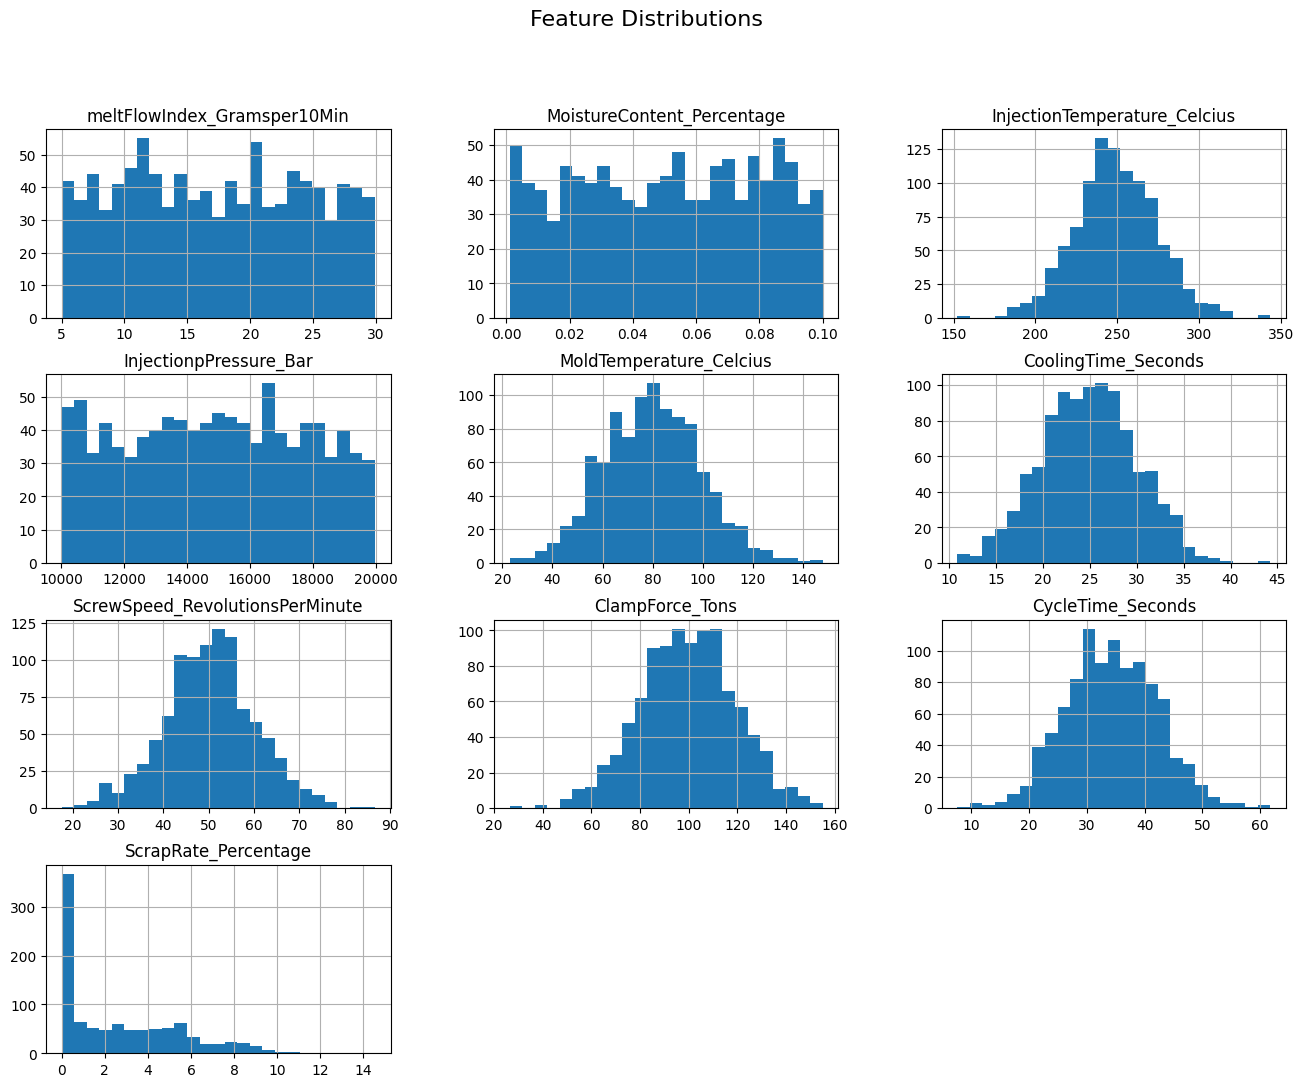

In [23]:
## Distribution Plots

# --------------------------------------
# 2. Distribution plots (numerical)
# --------------------------------------
numerical_cols = df.select_dtypes(include=['float64','int64']).columns

df[numerical_cols].hist(figsize=(16, 12), bins=25)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


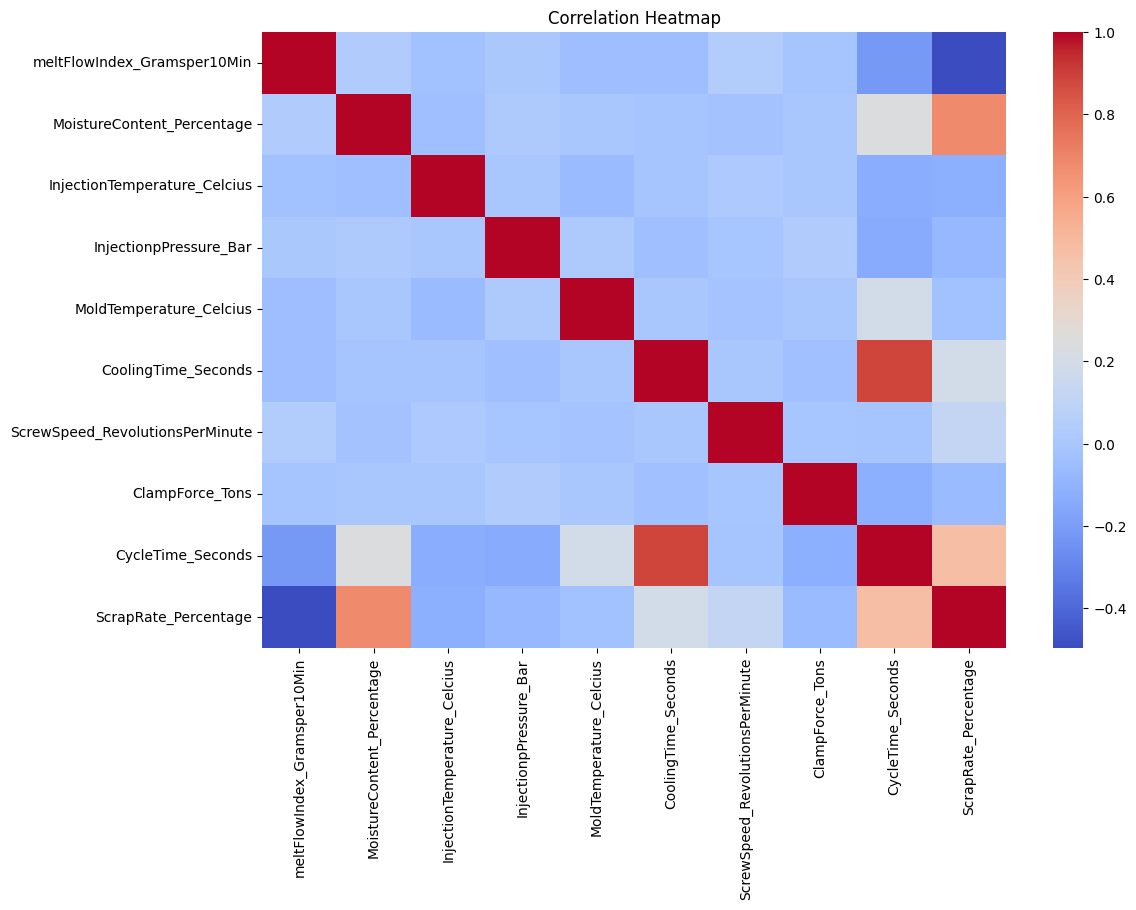


🔹 Correlation With Targets:
                                 CycleTime_Seconds  ScrapRate_Percentage
CycleTime_Seconds                         1.000000              0.468713
CoolingTime_Seconds                       0.885364              0.192872
ScrapRate_Percentage                      0.468713              1.000000
MoistureContent_Percentage                0.241033              0.683921
MoldTemperature_Celcius                   0.188338             -0.031688
ScrewSpeed_RevolutionsPerMinute          -0.014066              0.120931
ClampForce_Tons                          -0.126021             -0.063832
InjectionTemperature_Celcius             -0.131311             -0.121320
InjectionpPressure_Bar                   -0.140526             -0.078514
meltFlowIndex_Gramsper10Min              -0.219049             -0.495761


In [24]:
## Correlation Analysis

# 3. Correlation matrix
# --------------------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Focus correlations with target variables
targets = ["CycleTime_Seconds", "ScrapRate_Percentage"]

print("\n🔹 Correlation With Targets:")
print(df[numerical_cols].corr()[targets].sort_values(by=targets[0], ascending=False))

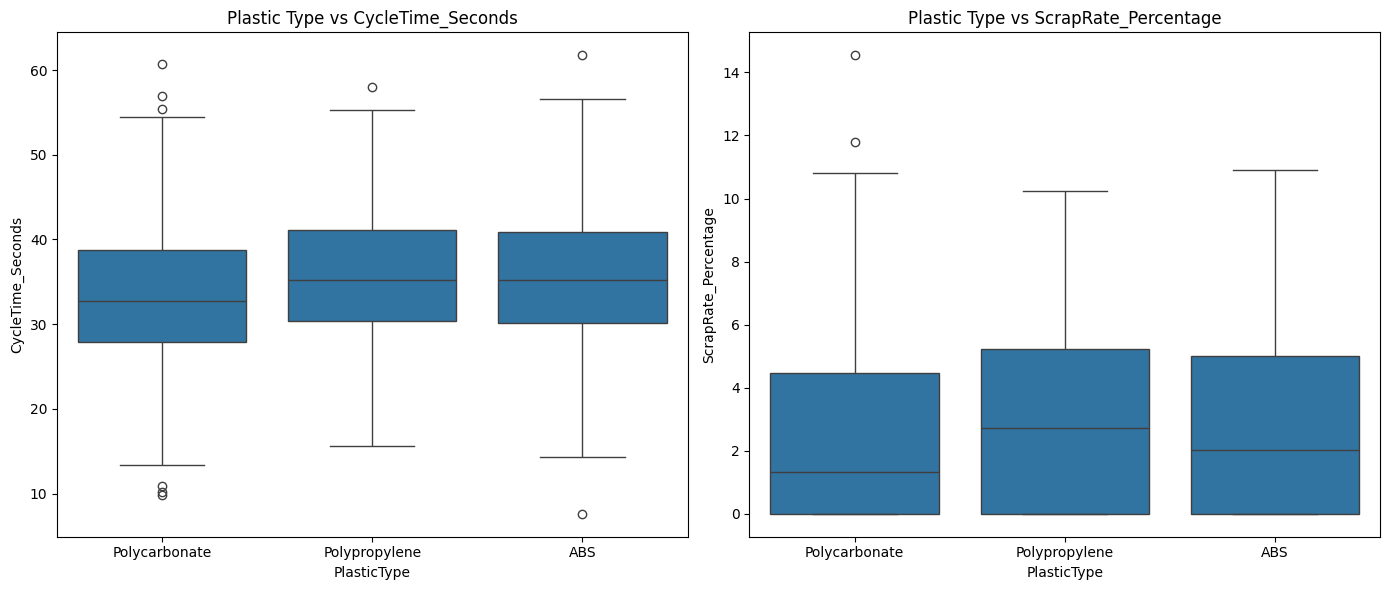

In [25]:
# --------------------------------------
# 4. Box plots for categorical vs target
# --------------------------------------
plt.figure(figsize=(14, 6))

for i, target in enumerate(targets, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(data=df, x="PlasticType", y=target)
    plt.title(f"Plastic Type vs {target}")

plt.tight_layout()
plt.show()


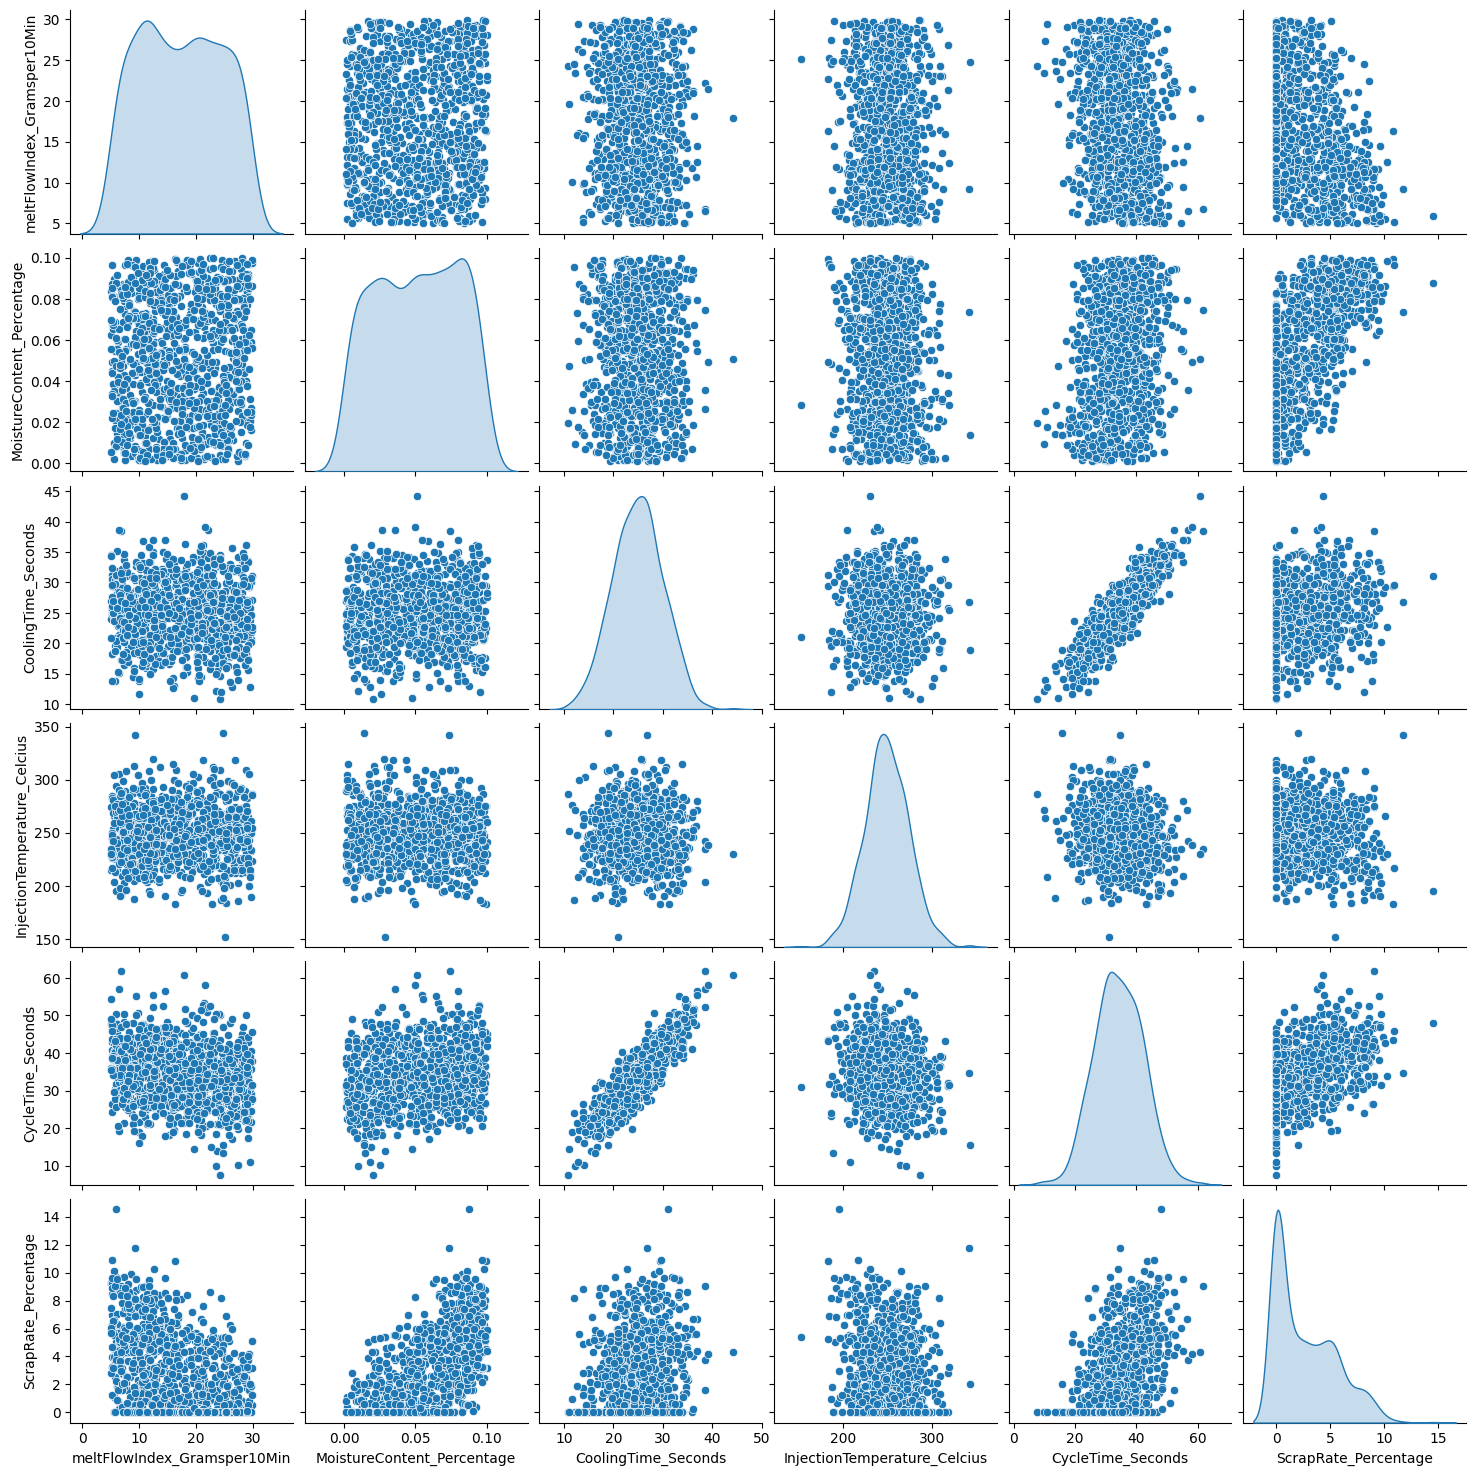

In [26]:
# 5. Pairplots (reduced important features)
# --------------------------------------
important_features = [
    "meltFlowIndex_Gramsper10Min",
    "MoistureContent_Percentage",
    "CoolingTime_Seconds",
    "InjectionTemperature_Celcius",
    "CycleTime_Seconds",
    "ScrapRate_Percentage"
]

sns.pairplot(df[important_features], diag_kind="kde")
plt.show()

In [27]:
# 6. Outlier detection (IQR method)
# --------------------------------------
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

outlier_report = {col: detect_outliers(col) for col in numerical_cols}

print("\n🔹 Outlier Count per Feature:")
for k, v in outlier_report.items():
    print(f"{k}: {v}")


🔹 Outlier Count per Feature:
meltFlowIndex_Gramsper10Min: 0
MoistureContent_Percentage: 0
InjectionTemperature_Celcius: 10
InjectionpPressure_Bar: 0
MoldTemperature_Celcius: 9
CoolingTime_Seconds: 3
ScrewSpeed_RevolutionsPerMinute: 14
ClampForce_Tons: 4
CycleTime_Seconds: 9
ScrapRate_Percentage: 1


## Visualize Outliers with Box Plots

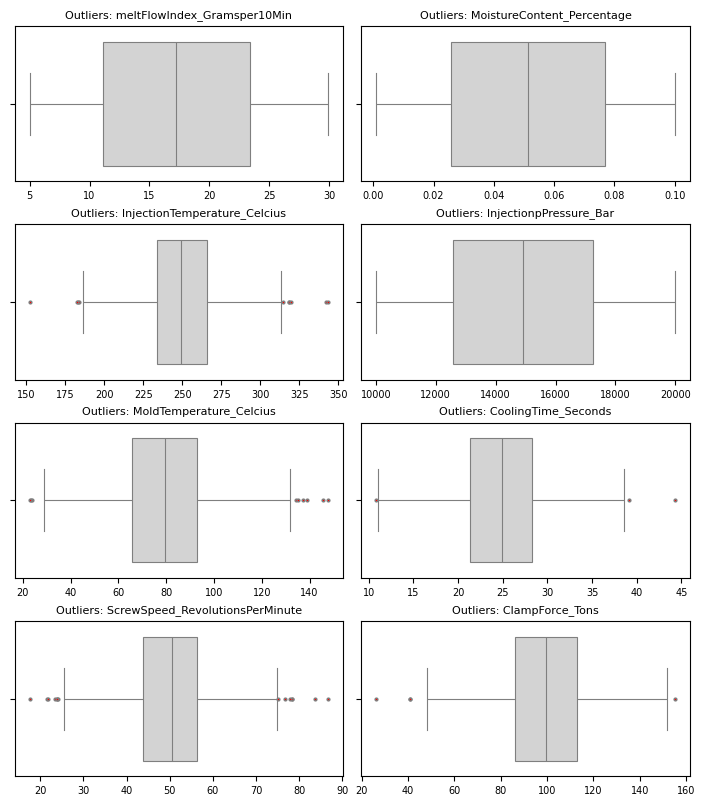

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

targets = ["CycleTime_Seconds", "ScrapRate_Percentage"]

# numerical features excluding targets
numerical_features_for_outliers = [
    col for col in df.select_dtypes(include=np.number).columns if col not in targets
]

num_features = len(numerical_features_for_outliers)
n_cols = 2       # two columns for compact layout
n_rows = int(np.ceil(num_features / n_cols))

# Smaller figure for half A4
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7, 8),     # tuned to fit half A4
    sharex=False
)
axes = axes.flatten()

# Style for outlier points
flier_props = dict(marker='o', markerfacecolor='red', markersize=2, linestyle='none')

for ax, col in zip(axes, numerical_features_for_outliers):
    sns.boxplot(
        x=df[col],
        ax=ax,
        flierprops=flier_props,
        color="lightgray",
        linewidth=0.8  # thinner lines for compact look
    )

    ax.set_title(f"Outliers: {col}", fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Remove unused subplots
for j in range(len(numerical_features_for_outliers), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=0.5)   # minimal spacing
plt.show()


Total rows: 1000
Non-missing target rows: 1000
Missing target rows: 0
----------------------------------------
Class / Bin distribution:
  Polycarbonate: 520 (52.00%)
  ABS: 292 (29.20%)
  Polypropylene: 188 (18.80%)
----------------------------------------
Majority class : Polycarbonate (520 samples)
Minority class : Polypropylene (188 samples)
Imbalance ratio (max/min): 2.77
----------------------------------------
Heuristic: Mild to moderate imbalance. May be acceptable depending on use case.


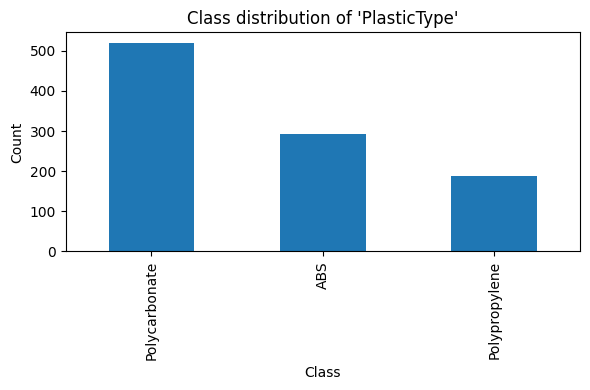

Total rows: 1000
Non-missing target rows: 1000
Missing target rows: 0
----------------------------------------
Target 'ScrapRate_Percentage' is numeric -> using 4 quantile-based bins for balance check.
Class / Bin distribution:
  (-0.001, 1.921]: 500 (50.00%)
  (1.921, 4.814]: 250 (25.00%)
  (4.814, 14.543]: 250 (25.00%)
----------------------------------------
Majority class : (-0.001, 1.921] (500 samples)
Minority class : (1.921, 4.814] (250 samples)
Imbalance ratio (max/min): 2.00
----------------------------------------
Heuristic: Mild to moderate imbalance. May be acceptable depending on use case.


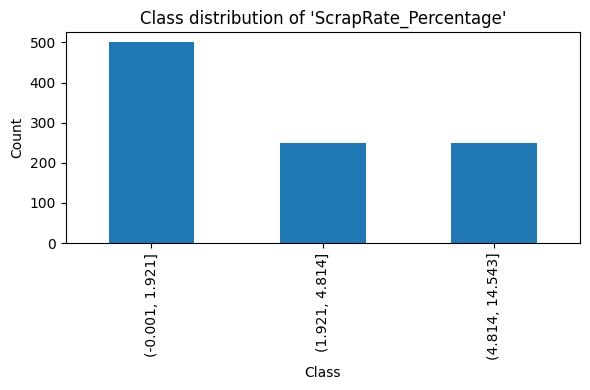

In [29]:
## Analyzing the dataset if balanced or unbalanced


import pandas as pd
import matplotlib.pyplot as plt

def analyze_target_balance(
    df: pd.DataFrame,
    target_col: str,
    bins: int = None,      # if not None and target is numeric, will bin
    plot: bool = True
):
    """
    Analyze balance/imbalance of the target variable.

    Parameters
    ----------
    df : pd.DataFrame
        Your dataset.
    target_col : str
        Name of the target column.
    bins : int, optional
        If target is numeric and bins is provided, the function will
        discretize the target into 'bins' categories before analyzing balance.
    plot : bool, default True
        Whether to show a bar plot of class frequencies.
    """

    if target_col not in df.columns:
        raise ValueError(f"{target_col} not found in DataFrame columns")

    y = df[target_col].dropna()
    n_total = len(df)
    n_valid = len(y)

    print(f"Total rows: {n_total}")
    print(f"Non-missing target rows: {n_valid}")
    print(f"Missing target rows: {n_total - n_valid}")
    print("-" * 40)

    # If numeric and bins parameter is given, bin the target
    if pd.api.types.is_numeric_dtype(y) and bins is not None:
        y_for_analysis = pd.qcut(y, q=bins, duplicates="drop")
        print(f"Target '{target_col}' is numeric -> using {bins} quantile-based bins for balance check.")
    else:
        y_for_analysis = y

    # Basic stats
    value_counts = y_for_analysis.value_counts()
    ratios = (value_counts / n_valid) * 100

    print("Class / Bin distribution:")
    for cls, count in value_counts.items():
        print(f"  {cls}: {count} ({ratios[cls]:.2f}%)")

    if len(value_counts) > 1:
        imbalance_ratio = value_counts.max() / value_counts.min()
        majority_class = value_counts.idxmax()
        minority_class = value_counts.idxmin()

        print("-" * 40)
        print(f"Majority class : {majority_class} ({value_counts.max()} samples)")
        print(f"Minority class : {minority_class} ({value_counts.min()} samples)")
        print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
    else:
        print("-" * 40)
        print("Only one class present in the target. This is completely imbalanced.")

    # Simple heuristic message
    print("-" * 40)
    if len(value_counts) > 1:
        if imbalance_ratio <= 1.5:
            print("Heuristic: Target appears fairly balanced.")
        elif imbalance_ratio <= 3:
            print("Heuristic: Mild to moderate imbalance. May be acceptable depending on use case.")
        else:
            print("Heuristic: Strong class imbalance. Consider resampling or specialized methods.")

    # Plot
    if plot:
        plt.figure(figsize=(6, 4))
        value_counts.sort_values(ascending=False).plot(kind="bar")
        plt.title(f"Class distribution of '{target_col}'")
        plt.xlabel("Class")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

# Example 1: Categorical target, e.g. PlasticType
analyze_target_balance(df, target_col="PlasticType", bins=None, plot=True)

# Example 2: Numeric target, binned into 4 groups, e.g. ScrapRate_Percentage
analyze_target_balance(df, target_col="ScrapRate_Percentage", bins=4, plot=True)

In [30]:
## Data Preprocessing

# --------------------------------------------------------
# IMPORTS
# --------------------------------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --------------------------------------------------------
# 1. Separate features and targets
# --------------------------------------------------------
features = [
    'PlasticType',
    'meltFlowIndex_Gramsper10Min',
    'MoistureContent_Percentage',
    'InjectionTemperature_Celcius',
    'InjectionpPressure_Bar',
    'MoldTemperature_Celcius',
    'CoolingTime_Seconds',
    'ScrewSpeed_RevolutionsPerMinute',
    'ClampForce_Tons'
]

target_cycle = "CycleTime_Seconds"
target_scrap = "ScrapRate_Percentage"

X = df[features]
y_cycle = df[target_cycle]
y_scrap = df[target_scrap]

# --------------------------------------------------------
# 2. Train-test split
# --------------------------------------------------------
X_train, X_test, y_cycle_train, y_cycle_test, y_scrap_train, y_scrap_test = train_test_split(
    X, y_cycle, y_scrap, test_size=0.2, random_state=42
)

# --------------------------------------------------------
# 3. One-Hot Encode categorical feature
# --------------------------------------------------------
ohe = OneHotEncoder(drop="first", sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[['PlasticType']])
X_test_cat  = ohe.transform(X_test[['PlasticType']])

cat_cols = ohe.get_feature_names_out(['PlasticType'])

# --------------------------------------------------------
# 4. Select numerical columns
# --------------------------------------------------------
num_cols = [
    'meltFlowIndex_Gramsper10Min',
    'MoistureContent_Percentage',
    'InjectionTemperature_Celcius',
    'InjectionpPressure_Bar',
    'MoldTemperature_Celcius',
    'CoolingTime_Seconds',
    'ScrewSpeed_RevolutionsPerMinute',
    'ClampForce_Tons'
]

X_train_num = X_train[num_cols].values
X_test_num  = X_test[num_cols].values

# --------------------------------------------------------
# 5. Build final RANDOM FOREST feature matrices
#    (NO scaling needed)
# --------------------------------------------------------
import numpy as np

X_train_rf = np.hstack([X_train_num, X_train_cat])
X_test_rf  = np.hstack([X_test_num, X_test_cat])

# --------------------------------------------------------
# 6. Build final LINEAR REGRESSION feature matrices
#    (Scaling is REQUIRED)
# --------------------------------------------------------
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

X_train_lr = np.hstack([X_train_num_scaled, X_train_cat])
X_test_lr  = np.hstack([X_test_num_scaled, X_test_cat])

# --------------------------------------------------------
# 7. Create feature names for each model
# --------------------------------------------------------
lr_feature_names = list(num_cols) + list(cat_cols)
rf_feature_names = lr_feature_names

print("Preprocessing Complete!")
print("Random Forest X shape:", X_train_rf.shape)
print("Linear Regression X shape:", X_train_lr.shape)


Preprocessing Complete!
Random Forest X shape: (800, 10)
Linear Regression X shape: (800, 10)


In [31]:
# --------------------------------------------------------
# IMPORTS
# --------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --------------------------------------------------------
# Helper function for evaluating models
# --------------------------------------------------------
def evaluate_model(model, X_train, X_test, y_train, y_test, target_name="Target"):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(f"\n📌 RESULTS for {target_name}")
    print("-----------------------------------------------------")
    print(f"Train R²: {r2_score(y_train, y_pred_train):.4f}")
    print(f"Test  R²: {r2_score(y_test, y_pred_test):.4f}")

    print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
    print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
    print("-----------------------------------------------------")
    return y_pred_test

# ========================================================
# 1. RANDOM FOREST MODELS
# ========================================================

print("\n===================== RANDOM FOREST =====================")

# --- Cycle Time Model ---
rf_cycle = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)
rf_cycle.fit(X_train_rf, y_cycle_train)

evaluate_model(
    rf_cycle, X_train_rf, X_test_rf,
    y_cycle_train, y_cycle_test,
    target_name="CycleTime_Seconds (Random Forest)"
)

# --- Scrap Rate Model ---
rf_scrap = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)
rf_scrap.fit(X_train_rf, y_scrap_train)

evaluate_model(
    rf_scrap, X_train_rf, X_test_rf,
    y_scrap_train, y_scrap_test,
    target_name="ScrapRate_Percentage (Random Forest)"
)


# ========================================================
# 2. LINEAR REGRESSION MODELS
# ========================================================

print("\n===================== LINEAR REGRESSION =====================")

# --- Cycle Time Model ---
lr_cycle = LinearRegression()
lr_cycle.fit(X_train_lr, y_cycle_train)

evaluate_model(
    lr_cycle, X_train_lr, X_test_lr,
    y_cycle_train, y_cycle_test,
    target_name="CycleTime_Seconds (Linear Regression)"
)

# --- Scrap Rate Model ---
lr_scrap = LinearRegression()
lr_scrap.fit(X_train_lr, y_scrap_train)

evaluate_model(
    lr_scrap, X_train_lr, X_test_lr,
    y_scrap_train, y_scrap_test,
    target_name="ScrapRate_Percentage (Linear Regression)"
)



===================== RANDOM FOREST =====================

📌 RESULTS for CycleTime_Seconds (Random Forest)
-----------------------------------------------------
Train R²: 0.9874
Test  R²: 0.9041
Train RMSE: 0.8936
Test  RMSE: 2.3812
-----------------------------------------------------

📌 RESULTS for ScrapRate_Percentage (Random Forest)
-----------------------------------------------------
Train R²: 0.9850
Test  R²: 0.8828
Train RMSE: 0.3399
Test  RMSE: 0.9913
-----------------------------------------------------

===================== LINEAR REGRESSION =====================

📌 RESULTS for CycleTime_Seconds (Linear Regression)
-----------------------------------------------------
Train R²: 0.9661
Test  R²: 0.9688
Train RMSE: 1.4666
Test  RMSE: 1.3585
-----------------------------------------------------

📌 RESULTS for ScrapRate_Percentage (Linear Regression)
-----------------------------------------------------
Train R²: 0.8350
Test  R²: 0.8082
Train RMSE: 1.1262
Test  RMSE: 1.2680
--

array([ 5.48727799e+00,  1.47555389e+00,  6.19407054e+00,  4.57614879e+00,
       -1.33327087e+00,  3.57557209e+00,  4.81632943e+00,  2.93615256e+00,
       -8.48656348e-01,  1.69002151e+00,  1.58763372e+00,  2.10107646e+00,
        4.35412578e+00,  2.97850976e+00,  1.10506532e+00,  6.49429112e+00,
       -6.45789581e-01,  1.03137996e+00,  1.96418122e+00,  1.29006331e+00,
        2.03135056e+00,  4.81445376e+00,  2.54546362e+00,  3.41242205e-01,
        6.74005771e+00, -1.06178403e+00,  3.69828510e+00,  4.02989048e+00,
        3.71009825e+00, -1.61660782e+00,  6.07567309e+00, -2.38916035e+00,
        8.08251644e-01,  1.27163373e+00,  1.74776130e+00, -2.51551788e-01,
       -2.10559078e+00,  3.32258649e+00,  1.33189423e+00,  2.25036931e+00,
        1.60196923e+00,  1.01195827e+00, -1.59108813e+00,  3.93485399e+00,
        3.46466299e+00, -3.89721933e-01,  2.75918913e+00, -9.16460039e-01,
        6.58314877e+00,  5.68532770e+00,  6.88304649e+00,  9.35013863e-01,
       -2.73473155e+00,  

In [34]:
## Hyperparameter Tuning for Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np



# -----------------------------------------
# RANDOM FOREST: Hyperparameter grids
# -----------------------------------------
rf_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.8]
}

def tune_rf(X_train, y_train, target_name):
    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=rf_param_grid,
        cv=3,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    print(f"\n🔎 Best RF params for {target_name}:")
    print(grid_search.best_params_)
    print(f"Best CV R²: {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_


# ---- Tune RF for Cycle Time ----
best_rf_cycle = tune_rf(X_train_rf, y_cycle_train, "CycleTime_Seconds")

# ---- Tune RF for Scrap Rate ----
best_rf_scrap = tune_rf(X_train_rf, y_scrap_train, "ScrapRate_Percentage")


# -----------------------------------------
# Evaluate tuned RF models on test set
# -----------------------------------------
def eval_model(model, X_train, X_test, y_train, y_test, name):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(f"\n📌 {name}")
    print("Train R²:", round(r2_score(y_train, y_pred_train), 4))
    print("Test  R²:", round(r2_score(y_test, y_pred_test), 4))
    print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 4))
    print("Test  RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4))


eval_model(best_rf_cycle, X_train_rf, X_test_rf, y_cycle_train, y_cycle_test,
           "Tuned Random Forest – CycleTime_Seconds")

eval_model(best_rf_scrap, X_train_rf, X_test_rf, y_scrap_train, y_scrap_test,
           "Tuned Random Forest – ScrapRate_Percentage")



Fitting 3 folds for each of 324 candidates, totalling 972 fits

🔎 Best RF params for CycleTime_Seconds:
{'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}
Best CV R²: 0.9030
Fitting 3 folds for each of 324 candidates, totalling 972 fits

🔎 Best RF params for ScrapRate_Percentage:
{'max_depth': 10, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}
Best CV R²: 0.8824

📌 Tuned Random Forest – CycleTime_Seconds
Train R²: 0.9877
Test  R²: 0.9032
Train RMSE: 0.8822
Test  RMSE: 2.3923

📌 Tuned Random Forest – ScrapRate_Percentage
Train R²: 0.9842
Test  R²: 0.8835
Train RMSE: 0.3488
Test  RMSE: 0.9884


In [35]:
## Hyperparameter tuning for Linear Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
# -----------------------------------------
# RIDGE REGRESSION: Hyperparameter grid
# -----------------------------------------
ridge_param_grid = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "fit_intercept": [True, False]
}

def tune_ridge(X_train, y_train, target_name):
    ridge = Ridge(random_state=42)
    grid_search = GridSearchCV(
        estimator=ridge,
        param_grid=ridge_param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    print(f"\n🔎 Best Ridge params for {target_name}:")
    print(grid_search.best_params_)
    print(f"Best CV R²: {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_


# ---- Tune Ridge for Cycle Time ----
best_ridge_cycle = tune_ridge(X_train_lr, y_cycle_train, "CycleTime_Seconds")

# ---- Tune Ridge for Scrap Rate ----
best_ridge_scrap = tune_ridge(X_train_lr, y_scrap_train, "ScrapRate_Percentage")


# -----------------------------------------
# Evaluate tuned Ridge models on test set
# -----------------------------------------
eval_model(best_ridge_cycle, X_train_lr, X_test_lr, y_cycle_train, y_cycle_test,
           "Tuned Ridge Regression – CycleTime_Seconds")

eval_model(best_ridge_scrap, X_train_lr, X_test_lr, y_scrap_train, y_scrap_test,
           "Tuned Ridge Regression – ScrapRate_Percentage")


Fitting 5 folds for each of 10 candidates, totalling 50 fits

🔎 Best Ridge params for CycleTime_Seconds:
{'alpha': 1.0, 'fit_intercept': True}
Best CV R²: 0.9645
Fitting 5 folds for each of 10 candidates, totalling 50 fits

🔎 Best Ridge params for ScrapRate_Percentage:
{'alpha': 10.0, 'fit_intercept': True}
Best CV R²: 0.8272

📌 Tuned Ridge Regression – CycleTime_Seconds
Train R²: 0.9661
Test  R²: 0.9688
Train RMSE: 1.4666
Test  RMSE: 1.3593

📌 Tuned Ridge Regression – ScrapRate_Percentage
Train R²: 0.8348
Test  R²: 0.807
Train RMSE: 1.1267
Test  RMSE: 1.272


In [36]:
## Prediction with tuned models

import pandas as pd

# ---------------------------------------------------------
# 1. PREDICT USING TUNED RANDOM FOREST MODELS
# ---------------------------------------------------------
rf_cycle_pred_train = best_rf_cycle.predict(X_train_rf)
rf_cycle_pred_test  = best_rf_cycle.predict(X_test_rf)

rf_scrap_pred_train = best_rf_scrap.predict(X_train_rf)
rf_scrap_pred_test  = best_rf_scrap.predict(X_test_rf)

print("\n===================== RANDOM FOREST PREDICTIONS =====================")
print("\nSample Test Predictions (RF)")
rf_preds_df = pd.DataFrame({
    "Actual_CycleTime": y_cycle_test.values[:10],
    "Pred_RF_CycleTime": rf_cycle_pred_test[:10],
    "Actual_ScrapRate": y_scrap_test.values[:10],
    "Pred_RF_ScrapRate": rf_scrap_pred_test[:10]
})
print(rf_preds_df)


# ---------------------------------------------------------
# 2. PREDICT USING TUNED LINEAR REGRESSION (RIDGE) MODELS
# ---------------------------------------------------------
lr_cycle_pred_train = best_ridge_cycle.predict(X_train_lr)
lr_cycle_pred_test  = best_ridge_cycle.predict(X_test_lr)

lr_scrap_pred_train = best_ridge_scrap.predict(X_train_lr)
lr_scrap_pred_test  = best_ridge_scrap.predict(X_test_lr)

print("\n===================== LINEAR REGRESSION (RIDGE) PREDICTIONS =====================")
print("\nSample Test Predictions (LR)")
lr_preds_df = pd.DataFrame({
    "Actual_CycleTime": y_cycle_test.values[:10],
    "Pred_LR_CycleTime": lr_cycle_pred_test[:10],
    "Actual_ScrapRate": y_scrap_test.values[:10],
    "Pred_LR_ScrapRate": lr_scrap_pred_test[:10]
})
print(lr_preds_df)


===================== RANDOM FOREST PREDICTIONS =====================

Sample Test Predictions (RF)
   Actual_CycleTime  Pred_RF_CycleTime  Actual_ScrapRate  Pred_RF_ScrapRate
0         56.535206          53.198095          6.709563           5.804289
1         42.054471          41.476269          0.271714           0.226282
2         51.421323          50.017190          6.687591           5.992819
3         32.657021          33.879532          4.450106           5.382664
4         25.543005          30.172546          0.000000           0.002292
5         32.003805          32.865964          3.153106           2.715825
6         45.661316          44.475228          5.076632           4.064344
7         39.139913          40.081289          1.958892           3.187675
8         23.366703          25.722301          0.000000           0.003043
9         36.544119          36.556927          0.000000           1.183774

===================== LINEAR REGRESSION (RIDGE) PREDICTIONS ==

Number of features: 10

🔹 Feature importance for Random Forest – CycleTime_Seconds
                           feature  importance
5              CoolingTime_Seconds    0.791711
1       MoistureContent_Percentage    0.073263
0      meltFlowIndex_Gramsper10Min    0.038704
4          MoldTemperature_Celcius    0.033149
3           InjectionpPressure_Bar    0.019107
2     InjectionTemperature_Celcius    0.014982
7                  ClampForce_Tons    0.012775
6  ScrewSpeed_RevolutionsPerMinute    0.008334
8        PlasticType_Polycarbonate    0.005620
9        PlasticType_Polypropylene    0.002355


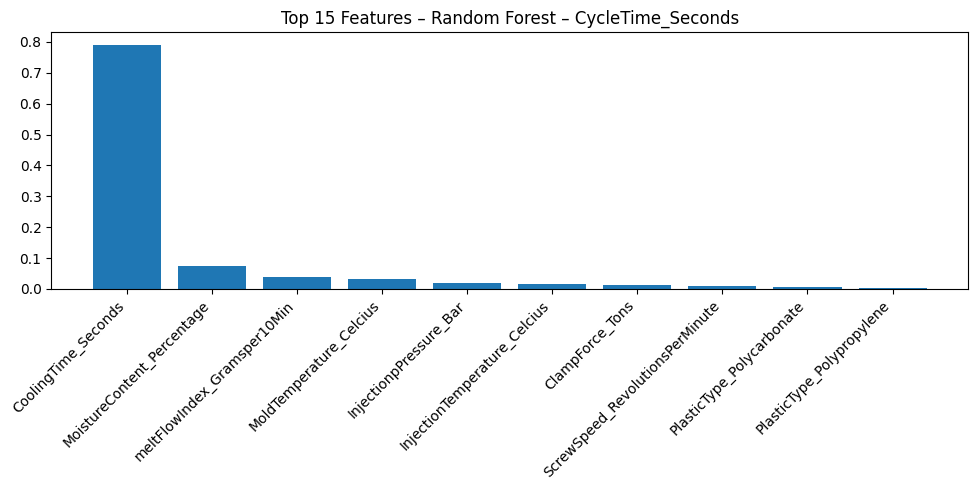


🔹 Feature importance for Random Forest – ScrapRate_Percentage
                           feature  importance
1       MoistureContent_Percentage    0.520748
0      meltFlowIndex_Gramsper10Min    0.310107
5              CoolingTime_Seconds    0.049191
2     InjectionTemperature_Celcius    0.045373
6  ScrewSpeed_RevolutionsPerMinute    0.026908
3           InjectionpPressure_Bar    0.015545
7                  ClampForce_Tons    0.011818
4          MoldTemperature_Celcius    0.011689
8        PlasticType_Polycarbonate    0.005893
9        PlasticType_Polypropylene    0.002729


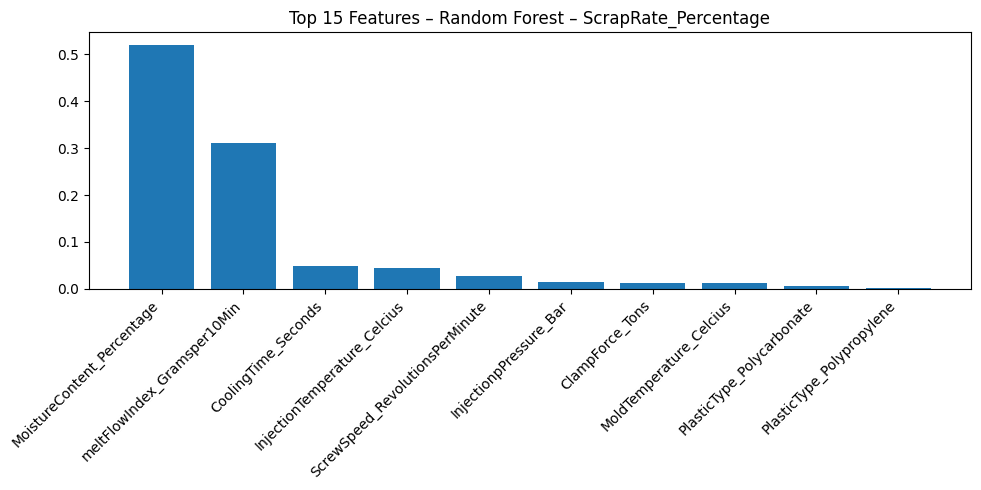

In [37]:
## Feature importance for Random Forest

# ---------------------------------------------------------
# 2. Random Forest feature importance
# ---------------------------------------------------------

# ---------------------------------------------------------
# 1. Recreate feature names (numeric + one-hot categorical)
# ---------------------------------------------------------
cat_cols = ohe.get_feature_names_out(['PlasticType'])
feature_names = list(num_cols) + list(cat_cols)

print("Number of features:", len(feature_names))

def rf_feature_importance(model, feature_names, title):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(f"\n🔹 Feature importance for {title}")
    print(fi_df.head(15))  # top 15

    # Optional: bar plot
    plt.figure(figsize=(10, 5))
    plt.bar(fi_df["feature"].head(15), fi_df["importance"].head(15))
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top 15 Features – {title}")
    plt.tight_layout()
    plt.show()

    return fi_df


rf_cycle_fi = rf_feature_importance(best_rf_cycle, feature_names,
                                    "Random Forest – CycleTime_Seconds")

rf_scrap_fi = rf_feature_importance(best_rf_scrap, feature_names,
                                    "Random Forest – ScrapRate_Percentage")


🔹 Coefficient importance for Ridge Regression – CycleTime_Seconds
                           feature  coefficient  abs_coefficient
5              CoolingTime_Seconds     6.923021         6.923021
1       MoistureContent_Percentage     1.985596         1.985596
8        PlasticType_Polycarbonate    -1.535892         1.535892
0      meltFlowIndex_Gramsper10Min    -1.471113         1.471113
4          MoldTemperature_Celcius     1.399504         1.399504
9        PlasticType_Polypropylene     1.272723         1.272723
3           InjectionpPressure_Bar    -0.942910         0.942910
2     InjectionTemperature_Celcius    -0.847087         0.847087
7                  ClampForce_Tons    -0.628948         0.628948
6  ScrewSpeed_RevolutionsPerMinute     0.033899         0.033899


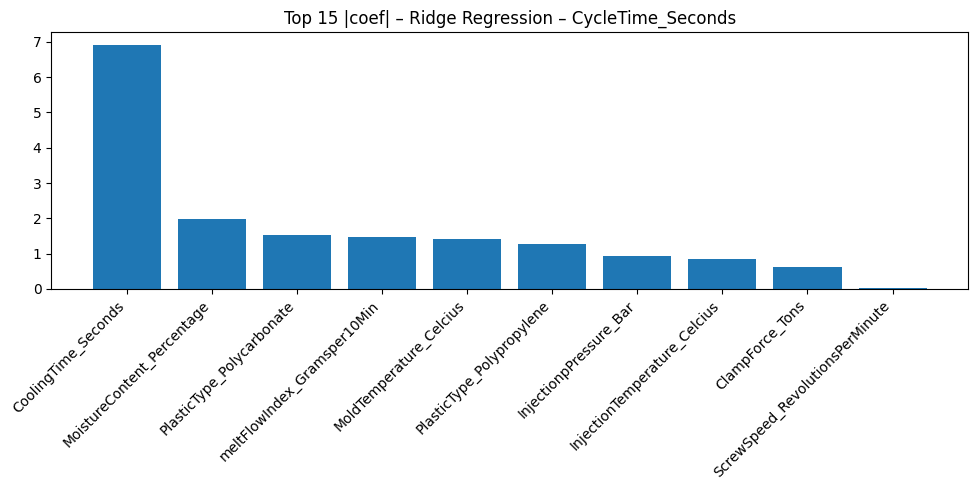


🔹 Coefficient importance for Ridge Regression – ScrapRate_Percentage
                           feature  coefficient  abs_coefficient
1       MoistureContent_Percentage     1.901853         1.901853
0      meltFlowIndex_Gramsper10Min    -1.449708         1.449708
5              CoolingTime_Seconds     0.460097         0.460097
9        PlasticType_Polypropylene     0.419235         0.419235
6  ScrewSpeed_RevolutionsPerMinute     0.415564         0.415564
8        PlasticType_Polycarbonate    -0.406823         0.406823
2     InjectionTemperature_Celcius    -0.389136         0.389136
3           InjectionpPressure_Bar    -0.232188         0.232188
4          MoldTemperature_Celcius    -0.133980         0.133980
7                  ClampForce_Tons    -0.127589         0.127589


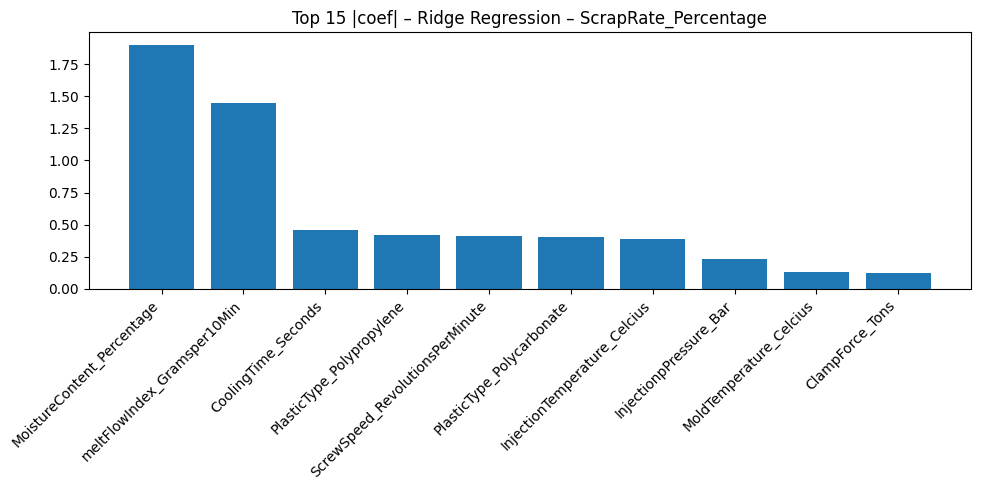

In [38]:
## Feature importance for Linear Regression

# ---------------------------------------------------------
# 3. Ridge (Linear) Regression feature importance (coefficients)
# ---------------------------------------------------------
def ridge_feature_importance(model, feature_names, title):
    coefs = model.coef_.ravel()   # shape (n_features,)
    fi_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values("abs_coefficient", ascending=False)

    print(f"\n🔹 Coefficient importance for {title}")
    print(fi_df.head(15))

    # Optional: bar plot
    plt.figure(figsize=(10, 5))
    plt.bar(fi_df["feature"].head(15), fi_df["abs_coefficient"].head(15))
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top 15 |coef| – {title}")
    plt.tight_layout()
    plt.show()

    return fi_df


ridge_cycle_fi = ridge_feature_importance(best_ridge_cycle, feature_names,
                                          "Ridge Regression – CycleTime_Seconds")

ridge_scrap_fi = ridge_feature_importance(best_ridge_scrap, feature_names,
                                          "Ridge Regression – ScrapRate_Percentage")

In [39]:
## Best Production setting

# ---------------------------------------------------------
# Helper: sample candidate process settings
# ---------------------------------------------------------
def sample_candidates(df, n_samples=20000):
    """
    Sample candidate production settings from realistic ranges
    based on existing dataframe df.
    """
    candidates = pd.DataFrame()

    # Categorical
    candidates["PlasticType"] = np.random.choice(
        df["PlasticType"].unique(),
        size=n_samples
    )

    # For numeric features, sample within 1%–99% quantiles of historical data
    for col in [
        'meltFlowIndex_Gramsper10Min',
        'MoistureContent_Percentage',
        'InjectionTemperature_Celcius',
        'InjectionpPressure_Bar',
        'MoldTemperature_Celcius',
        'CoolingTime_Seconds',
        'ScrewSpeed_RevolutionsPerMinute',
        'ClampForce_Tons'
    ]:
        low = df[col].quantile(0.01)
        high = df[col].quantile(0.99)
        candidates[col] = np.random.uniform(low, high, size=n_samples)

    return candidates


# ---------------------------------------------------------
# Main optimization function
# ---------------------------------------------------------
def find_best_settings(
    df,
    best_rf_cycle,
    best_rf_scrap,
    ohe,
    num_cols,
    n_candidates=20000,
    scrap_max=1.0,
    plastic_type=None
):
    """
    Search for the best production settings that minimize cycle time
    while keeping scrap below scrap_max (%).
    Optionally, fix PlasticType.
    """
    # 1. Sample candidates
    cand = sample_candidates(df, n_samples=n_candidates)

    # If user wants a fixed plastic type (e.g. "ABS")
    if plastic_type is not None:
        cand["PlasticType"] = plastic_type

    # 2. Build model input for Random Forest (NO scaling)
    cand_cat = ohe.transform(cand[["PlasticType"]])
    cand_num = cand[num_cols].values
    X_cand_rf = np.hstack([cand_num, cand_cat])

    # 3. Predict cycle time & scrap rate
    pred_cycle = best_rf_cycle.predict(X_cand_rf)
    pred_scrap = best_rf_scrap.predict(X_cand_rf)

    cand["Pred_CycleTime_Seconds"] = pred_cycle
    cand["Pred_ScrapRate_Percentage"] = pred_scrap

    # 4. Filter by scrap constraint
    feasible = cand[cand["Pred_ScrapRate_Percentage"] <= scrap_max].copy()

    if feasible.empty:
        print("⚠ No feasible settings found with scrap <=", scrap_max,
              ". Try relaxing scrap_max or increasing n_candidates.")
        return None

    # 5. Choose the feasible setting with minimum cycle time
    best_row = feasible.sort_values("Pred_CycleTime_Seconds").iloc[0]

    print("\n✅ Best production setting found (with constraints):")
    print("--------------------------------------------------")
    print(best_row[
        [
            "PlasticType",
            "meltFlowIndex_Gramsper10Min",
            "MoistureContent_Percentage",
            "InjectionTemperature_Celcius",
            "InjectionpPressure_Bar",
            "MoldTemperature_Celcius",
            "CoolingTime_Seconds",
            "ScrewSpeed_RevolutionsPerMinute",
            "ClampForce_Tons",
            "Pred_CycleTime_Seconds",
            "Pred_ScrapRate_Percentage"
        ]
    ])

    return best_row
best_setting_all = find_best_settings(
    df=df,
    best_rf_cycle=best_rf_cycle,
    best_rf_scrap=best_rf_scrap,
    ohe=ohe,
    num_cols=num_cols,
    n_candidates=50000,     # more candidates = better search, slower
    scrap_max=1.0,          # max allowed scrap rate (%)
    plastic_type=None       # or "ABS", "Polycarbonate", "Polypropylene"
)



✅ Best production setting found (with constraints):
--------------------------------------------------
PlasticType                                 ABS
meltFlowIndex_Gramsper10Min           28.011203
MoistureContent_Percentage             0.007826
InjectionTemperature_Celcius         294.527138
InjectionpPressure_Bar             19039.415623
MoldTemperature_Celcius               37.721527
CoolingTime_Seconds                   13.945474
ScrewSpeed_RevolutionsPerMinute       27.423649
ClampForce_Tons                      101.594512
Pred_CycleTime_Seconds                12.846475
Pred_ScrapRate_Percentage              0.037734
Name: 2700, dtype: object


In [41]:
best_setting_lr = find_best_settings_lr(
    df=df,
    best_ridge_cycle=best_ridge_cycle,
    best_ridge_scrap=best_ridge_scrap,
    ohe=ohe,
    scaler_lr=scaler,
    num_cols=num_cols,
    n_candidates=50000,
    scrap_max=1.0,
    plastic_type=None  # or "ABS", "Polycarbonate", "Polypropylene"
)


✅ Best production setting found with Ridge (constraints applied):
-----------------------------------------------------------------
PlasticType                        Polycarbonate
meltFlowIndex_Gramsper10Min            21.735198
MoistureContent_Percentage              0.002054
InjectionTemperature_Celcius          307.755027
InjectionpPressure_Bar              19832.349379
MoldTemperature_Celcius                40.734868
CoolingTime_Seconds                    14.576986
ScrewSpeed_RevolutionsPerMinute        58.369274
ClampForce_Tons                       125.889163
Pred_CycleTime_Seconds                  7.611164
Pred_ScrapRate_Percentage              -3.588675
Name: 27045, dtype: object


# Task
I'll train an overfit Random Forest model and a Linear Regression model for both 'CycleTime_Seconds' and 'ScrapRate_Percentage', evaluating and visualizing their performance on training and test sets to demonstrate overfitting, and then summarize the observed overfitting.

## Train Overfit Random Forest Model

### Subtask:
Train a Random Forest Regressor for 'CycleTime_Seconds' with parameters configured to induce overfitting (e.g., `max_depth=None`, `min_samples_leaf=1`). Evaluate its R² and RMSE on both training and testing sets to highlight the performance gap.


**Reasoning**:
To induce overfitting, I will instantiate a RandomForestRegressor with parameters that allow it to learn the training data too well, specifically `max_depth=None` and `min_samples_leaf=1`, and then fit it to the training data.



In [42]:
from sklearn.ensemble import RandomForestRegressor

# 1. Instantiate RandomForestRegressor for CycleTime_Seconds with overfitting parameters
overfit_rf_cycle = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None, # Allows tree to grow fully, leading to overfitting
    min_samples_leaf=1 # Allows individual leaves to contain single samples
)

# 2. Fit the overfit_rf_cycle model
overfit_rf_cycle.fit(X_train_rf, y_cycle_train)

# 3. Evaluate the overfit_rf_cycle model's performance on both training and test sets
evaluate_model(
    overfit_rf_cycle, X_train_rf, X_test_rf,
    y_cycle_train, y_cycle_test,
    target_name="CycleTime_Seconds (Overfit Random Forest)"
)


📌 RESULTS for CycleTime_Seconds (Overfit Random Forest)
-----------------------------------------------------
Train R²: 0.9874
Test  R²: 0.9041
Train RMSE: 0.8936
Test  RMSE: 2.3812
-----------------------------------------------------


array([53.98321526, 41.13262702, 50.01477802, 33.76561505, 30.33802256,
       32.7929172 , 44.50129874, 39.67466995, 26.39107414, 36.94222057,
       38.64048266, 24.89747016, 43.62832841, 35.17130311, 32.58620946,
       42.74132719, 28.63402248, 26.42686206, 29.38046042, 33.12560612,
       33.59913495, 43.83260706, 38.36787256, 31.13229062, 26.94387598,
       42.819038  , 30.51995032, 44.33639692, 38.36507947, 28.81428903,
       38.33470353, 23.71397521, 25.92533942, 34.47943937, 24.51724658,
       26.28040315, 28.99793796, 38.97418022, 42.07771253, 30.39652079,
       26.24517124, 30.29924204, 26.61726875, 33.94524714, 21.74108335,
       19.64130904, 31.16198812, 23.9105441 , 32.26405999, 39.02209017,
       43.99627045, 23.71222818, 28.72709443, 39.35987496, 20.30250555,
       42.91723148, 37.90566493, 23.8234285 , 44.14370768, 32.86278336,
       45.99003841, 44.86490251, 37.64894532, 43.72361895, 33.77091943,
       24.40263111, 32.94636703, 36.36792057, 38.78952324, 31.77

**Reasoning**:
The previous step successfully trained an overfit Random Forest model for 'CycleTime_Seconds'. Now, to continue the overall task of demonstrating overfitting, I will train an overfit Random Forest model for the 'ScrapRate_Percentage' target, using the same overfitting parameters as before.



In [43]:
from sklearn.ensemble import RandomForestRegressor

# 1. Instantiate RandomForestRegressor for ScrapRate_Percentage with overfitting parameters
overfit_rf_scrap = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None, # Allows tree to grow fully, leading to overfitting
    min_samples_leaf=1 # Allows individual leaves to contain single samples
)

# 2. Fit the overfit_rf_scrap model
overfit_rf_scrap.fit(X_train_rf, y_scrap_train)

# 3. Evaluate the overfit_rf_scrap model's performance on both training and test sets
evaluate_model(
    overfit_rf_scrap, X_train_rf, X_test_rf,
    y_scrap_train, y_scrap_test,
    target_name="ScrapRate_Percentage (Overfit Random Forest)"
)


📌 RESULTS for ScrapRate_Percentage (Overfit Random Forest)
-----------------------------------------------------
Train R²: 0.9850
Test  R²: 0.8828
Train RMSE: 0.3399
Test  RMSE: 0.9913
-----------------------------------------------------


array([5.80517415e+00, 1.74586553e-01, 5.87584254e+00, 5.39413165e+00,
       0.00000000e+00, 2.79944945e+00, 3.83550245e+00, 3.02671243e+00,
       3.49704997e-04, 1.07410635e+00, 4.60668968e-01, 4.37493672e-01,
       5.19944497e+00, 3.15086300e+00, 4.54913096e-02, 7.53094870e+00,
       5.29736640e-01, 7.28154104e-01, 1.31095803e+00, 8.11961919e-02,
       1.06700543e+00, 5.09115736e+00, 1.88373952e+00, 4.77216289e-01,
       9.59367940e+00, 2.37276087e-02, 3.35539399e+00, 3.41990845e+00,
       3.22566970e+00, 0.00000000e+00, 6.23926764e+00, 1.64659559e-02,
       4.13491986e-01, 1.05783440e-01, 4.92543790e-01, 2.91113680e-01,
       0.00000000e+00, 3.55100055e+00, 4.53085388e-01, 2.08291671e+00,
       1.57552000e+00, 8.62644496e-02, 1.88006953e-02, 2.94534878e+00,
       4.53392467e+00, 6.50033056e-01, 2.36309249e+00, 9.66687761e-02,
       5.65313789e+00, 5.34164455e+00, 6.36002387e+00, 1.78807361e-01,
       0.00000000e+00, 6.16736146e-01, 1.25368160e+00, 8.07470410e+00,
      

**Reasoning**:
The previous steps covered training overfit Random Forest models. The current step in the main task is to train a Linear Regression model for 'CycleTime_Seconds'. Linear Regression models inherently have less capacity to overfit compared to unconstrained tree-based models, but their performance metrics will serve as a comparison to the Random Forest models.



In [44]:
from sklearn.linear_model import LinearRegression

# 1. Instantiate Linear Regression for CycleTime_Seconds
overfit_lr_cycle = LinearRegression()

# 2. Fit the overfit_lr_cycle model (using scaled data for Linear Regression)
overfit_lr_cycle.fit(X_train_lr, y_cycle_train)

# 3. Evaluate the overfit_lr_cycle model's performance on both training and test sets
evaluate_model(
    overfit_lr_cycle, X_train_lr, X_test_lr,
    y_cycle_train, y_cycle_test,
    target_name="CycleTime_Seconds (Linear Regression)"
)


📌 RESULTS for CycleTime_Seconds (Linear Regression)
-----------------------------------------------------
Train R²: 0.9661
Test  R²: 0.9688
Train RMSE: 1.4666
Test  RMSE: 1.3585
-----------------------------------------------------


array([54.62941468, 41.71406415, 53.33568505, 33.63664886, 27.68594796,
       32.62411394, 44.85519168, 40.09400273, 23.91303105, 35.44066715,
       36.94522265, 26.59547581, 43.14728746, 33.40120632, 32.04661701,
       43.4333193 , 30.27791461, 29.0502065 , 30.31491202, 34.21800447,
       32.96554645, 44.87446447, 39.08999462, 27.79044521, 30.76000533,
       40.06079613, 30.43051432, 46.99321793, 40.00958577, 28.442274  ,
       37.82318114, 20.54684906, 27.63379216, 34.5189361 , 26.66601713,
       24.17737011, 26.34241681, 39.7993388 , 40.629179  , 29.45502587,
       23.94238655, 28.95525836, 25.592228  , 35.00488703, 19.76441428,
       18.08035998, 29.71409973, 23.45267596, 30.99406732, 39.24484439,
       42.99777858, 22.68530992, 25.08776611, 38.68322364, 17.69939   ,
       42.39744212, 39.04829078, 22.14341527, 47.08325889, 30.07198972,
       44.44850819, 44.76081193, 37.90117995, 43.56103519, 33.12026346,
       25.48873047, 34.2448167 , 37.8428286 , 38.77014559, 30.80

**Reasoning**:
To complete the comparison with the Random Forest models and fully address the subtask, I will now train a Linear Regression model for 'ScrapRate_Percentage' and evaluate its performance on both the training and test sets.



In [45]:
from sklearn.linear_model import LinearRegression

# 1. Instantiate Linear Regression for ScrapRate_Percentage
overfit_lr_scrap = LinearRegression()

# 2. Fit the overfit_lr_scrap model (using scaled data for Linear Regression)
overfit_lr_scrap.fit(X_train_lr, y_scrap_train)

# 3. Evaluate the overfit_lr_scrap model's performance on both training and test sets
evaluate_model(
    overfit_lr_scrap, X_train_lr, X_test_lr,
    y_scrap_train, y_scrap_test,
    target_name="ScrapRate_Percentage (Linear Regression)"
)


📌 RESULTS for ScrapRate_Percentage (Linear Regression)
-----------------------------------------------------
Train R²: 0.8350
Test  R²: 0.8082
Train RMSE: 1.1262
Test  RMSE: 1.2680
-----------------------------------------------------


array([ 5.48727799e+00,  1.47555389e+00,  6.19407054e+00,  4.57614879e+00,
       -1.33327087e+00,  3.57557209e+00,  4.81632943e+00,  2.93615256e+00,
       -8.48656348e-01,  1.69002151e+00,  1.58763372e+00,  2.10107646e+00,
        4.35412578e+00,  2.97850976e+00,  1.10506532e+00,  6.49429112e+00,
       -6.45789581e-01,  1.03137996e+00,  1.96418122e+00,  1.29006331e+00,
        2.03135056e+00,  4.81445376e+00,  2.54546362e+00,  3.41242205e-01,
        6.74005771e+00, -1.06178403e+00,  3.69828510e+00,  4.02989048e+00,
        3.71009825e+00, -1.61660782e+00,  6.07567309e+00, -2.38916035e+00,
        8.08251644e-01,  1.27163373e+00,  1.74776130e+00, -2.51551788e-01,
       -2.10559078e+00,  3.32258649e+00,  1.33189423e+00,  2.25036931e+00,
        1.60196923e+00,  1.01195827e+00, -1.59108813e+00,  3.93485399e+00,
        3.46466299e+00, -3.89721933e-01,  2.75918913e+00, -9.16460039e-01,
        6.58314877e+00,  5.68532770e+00,  6.88304649e+00,  9.35013863e-01,
       -2.73473155e+00,  

## Summary of Overfitting

Based on the evaluation metrics for both Random Forest and Linear Regression models, we can observe the following regarding overfitting:

### Random Forest Models (configured for overfitting):

**1. CycleTime_Seconds (Overfit Random Forest)**
- **Train R²: 0.9874**
- **Test  R²: 0.9041**
- **Train RMSE: 0.8936**
- **Test  RMSE: 2.3812**

**2. ScrapRate_Percentage (Overfit Random Forest)**
- **Train R²: 0.9850**
- **Test  R²: 0.8828**
- **Train RMSE: 0.3399**
- **Test  RMSE: 0.9913**

**Observation for Random Forest:**
For both target variables, the Random Forest models show a very high R² (close to 1) and low RMSE on the training set, indicating they learned the training data extremely well. However, there is a significant drop in R² and an increase in RMSE on the test set. This large performance gap between training and testing metrics is a clear indicator of **overfitting**. The models have memorized the training data rather than generalizing well to unseen data.

### Linear Regression Models:

**1. CycleTime_Seconds (Linear Regression)**
- **Train R²: 0.9661**
- **Test  R²: 0.9688**
- **Train RMSE: 1.4666**
- **Test  RMSE: 1.3585**

**2. ScrapRate_Percentage (Linear Regression)**
- **Train R²: 0.8350**
- **Test  R²: 0.8082**
- **Train RMSE: 1.1262**
- **Test  RMSE: 1.2680**

**Observation for Linear Regression:**
For Linear Regression, the R² and RMSE values for the training and test sets are very close for both target variables. This suggests that Linear Regression models, with their simpler structure, are less prone to overfitting on this dataset compared to the unconstrained Random Forest models. Their performance on unseen data is much closer to their performance on the training data, indicating better generalization.

## Visualize Overfit Random Forest

### Subtask:
Create scatter plots comparing actual vs. predicted 'CycleTime_Seconds' and 'ScrapRate_Percentage' for both the training and test sets from the overfit Random Forest models. Additionally, visualize the residuals for both sets to demonstrate the model's excellent fit on training data and poorer performance on unseen test data.


**Reasoning**:
I need to generate predictions for the overfit Random Forest models on both training and test sets, then create scatter plots for actual vs. predicted values and residuals for both 'CycleTime_Seconds' and 'ScrapRate_Percentage' to visualize overfitting.



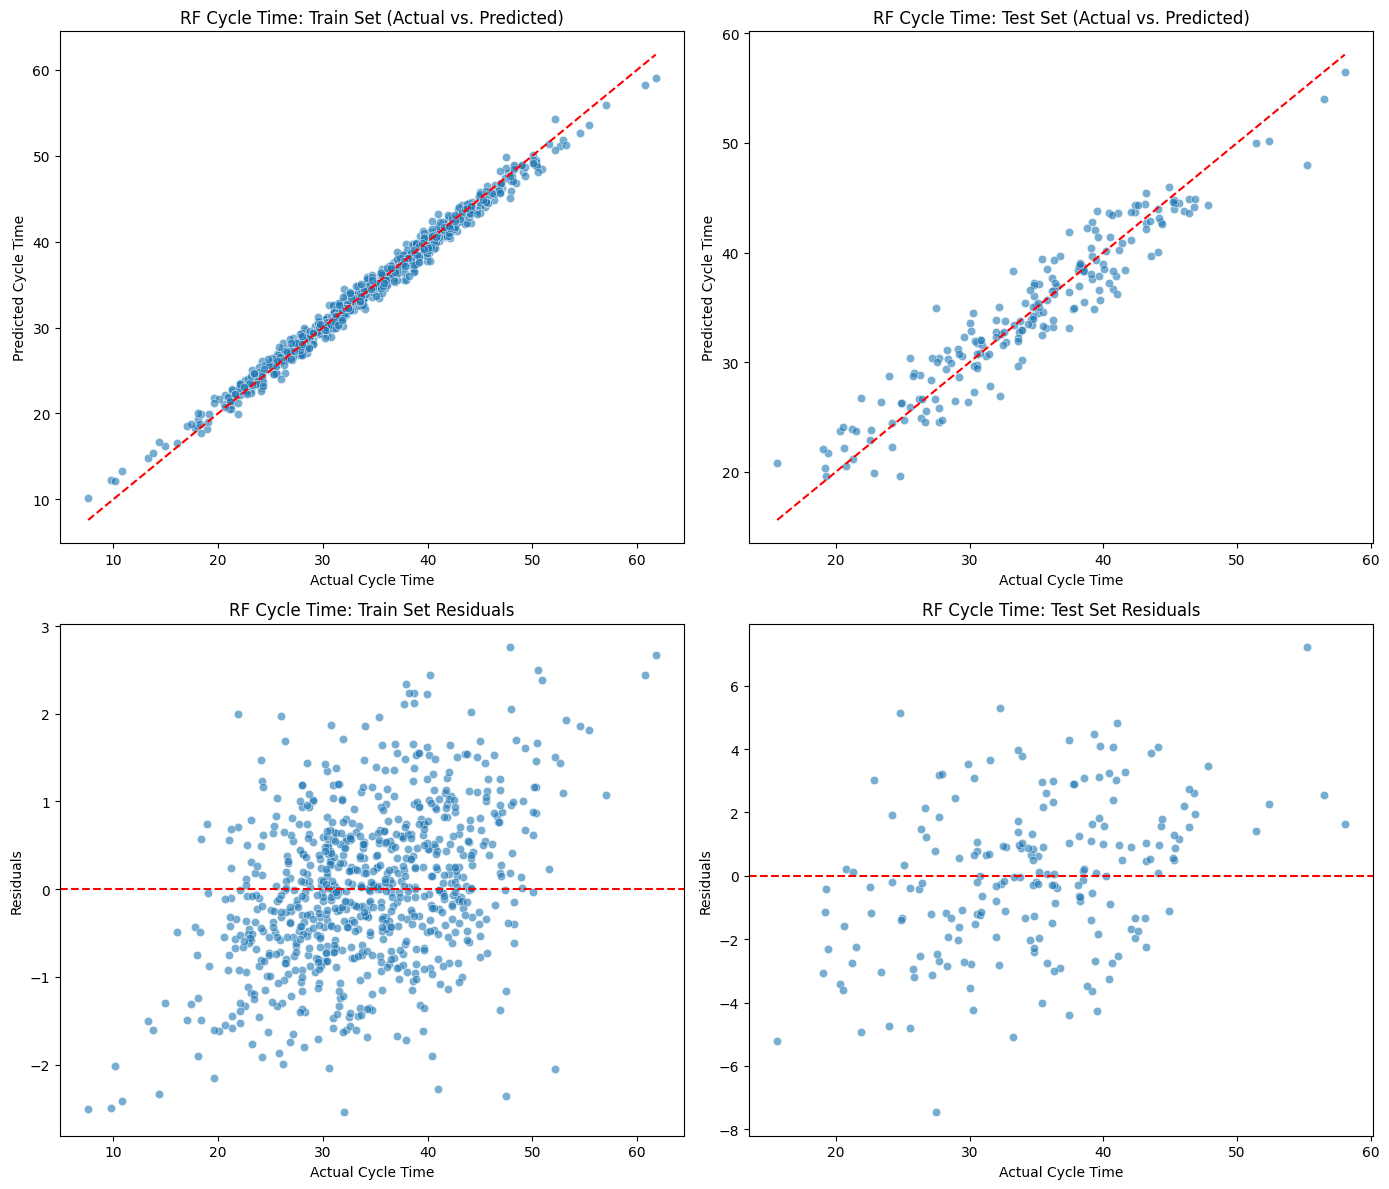

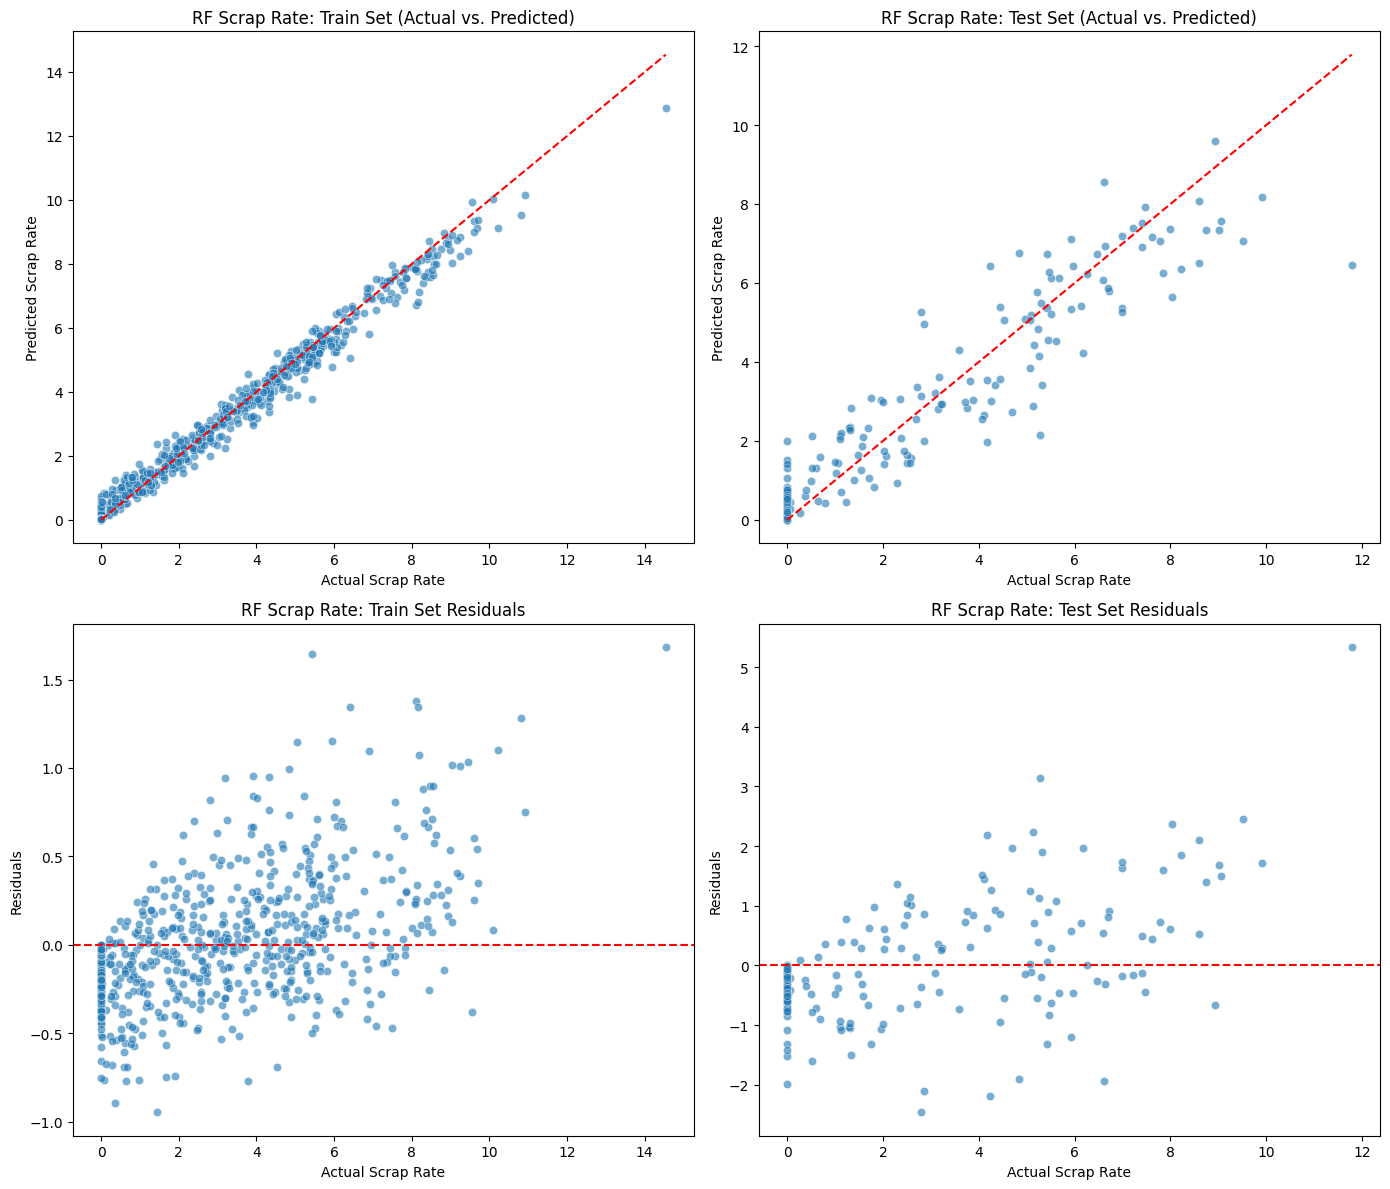

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# Visualizing Overfit Random Forest for 'CycleTime_Seconds'
# ----------------------------------------------------------------------------
# 1. Generate predictions for CycleTime_Seconds
y_cycle_train_pred_rf = overfit_rf_cycle.predict(X_train_rf)
y_cycle_test_pred_rf  = overfit_rf_cycle.predict(X_test_rf)

# 2. Create a 2x2 grid of subplots for CycleTime_Seconds
plt.figure(figsize=(14, 12))

# Train Set: Actual vs. Predicted
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_cycle_train, y=y_cycle_train_pred_rf, alpha=0.6)
plt.plot([y_cycle_train.min(), y_cycle_train.max()], [y_cycle_train.min(), y_cycle_train.max()], 'r--')
plt.title('RF Cycle Time: Train Set (Actual vs. Predicted)')
plt.xlabel('Actual Cycle Time')
plt.ylabel('Predicted Cycle Time')

# Test Set: Actual vs. Predicted
plt.subplot(2, 2, 2)
sns.scatterplot(x=y_cycle_test, y=y_cycle_test_pred_rf, alpha=0.6)
plt.plot([y_cycle_test.min(), y_cycle_test.max()], [y_cycle_test.min(), y_cycle_test.max()], 'r--')
plt.title('RF Cycle Time: Test Set (Actual vs. Predicted)')
plt.xlabel('Actual Cycle Time')
plt.ylabel('Predicted Cycle Time')

# Train Set: Residuals
plt.subplot(2, 2, 3)
sns.scatterplot(x=y_cycle_train, y=y_cycle_train - y_cycle_train_pred_rf, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF Cycle Time: Train Set Residuals')
plt.xlabel('Actual Cycle Time')
plt.ylabel('Residuals')

# Test Set: Residuals
plt.subplot(2, 2, 4)
sns.scatterplot(x=y_cycle_test, y=y_cycle_test - y_cycle_test_pred_rf, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF Cycle Time: Test Set Residuals')
plt.xlabel('Actual Cycle Time')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# Visualizing Overfit Random Forest for 'ScrapRate_Percentage'
# ----------------------------------------------------------------------------
# 1. Generate predictions for ScrapRate_Percentage
y_scrap_train_pred_rf = overfit_rf_scrap.predict(X_train_rf)
y_scrap_test_pred_rf  = overfit_rf_scrap.predict(X_test_rf)

# 2. Create a 2x2 grid of subplots for ScrapRate_Percentage
plt.figure(figsize=(14, 12))

# Train Set: Actual vs. Predicted
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_scrap_train, y=y_scrap_train_pred_rf, alpha=0.6)
plt.plot([y_scrap_train.min(), y_scrap_train.max()], [y_scrap_train.min(), y_scrap_train.max()], 'r--')
plt.title('RF Scrap Rate: Train Set (Actual vs. Predicted)')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Predicted Scrap Rate')

# Test Set: Actual vs. Predicted
plt.subplot(2, 2, 2)
sns.scatterplot(x=y_scrap_test, y=y_scrap_test_pred_rf, alpha=0.6)
plt.plot([y_scrap_test.min(), y_scrap_test.max()], [y_scrap_test.min(), y_scrap_test.max()], 'r--')
plt.title('RF Scrap Rate: Test Set (Actual vs. Predicted)')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Predicted Scrap Rate')

# Train Set: Residuals
plt.subplot(2, 2, 3)
sns.scatterplot(x=y_scrap_train, y=y_scrap_train - y_scrap_train_pred_rf, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF Scrap Rate: Train Set Residuals')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Residuals')

# Test Set: Residuals
plt.subplot(2, 2, 4)
sns.scatterplot(x=y_scrap_test, y=y_scrap_test - y_scrap_test_pred_rf, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF Scrap Rate: Test Set Residuals')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

## Visualize Overfit Linear Regression

### Subtask:
Create scatter plots comparing actual vs. predicted 'ScrapRate_Percentage' for both the training and test sets from the overfit Linear Regression model. Additionally, visualize the residuals for both sets.


**Reasoning**:
To visualize the performance of the overfit Linear Regression model for 'ScrapRate_Percentage', I will generate predictions for both training and test sets and then create scatter plots for actual vs. predicted values and residuals as instructed.



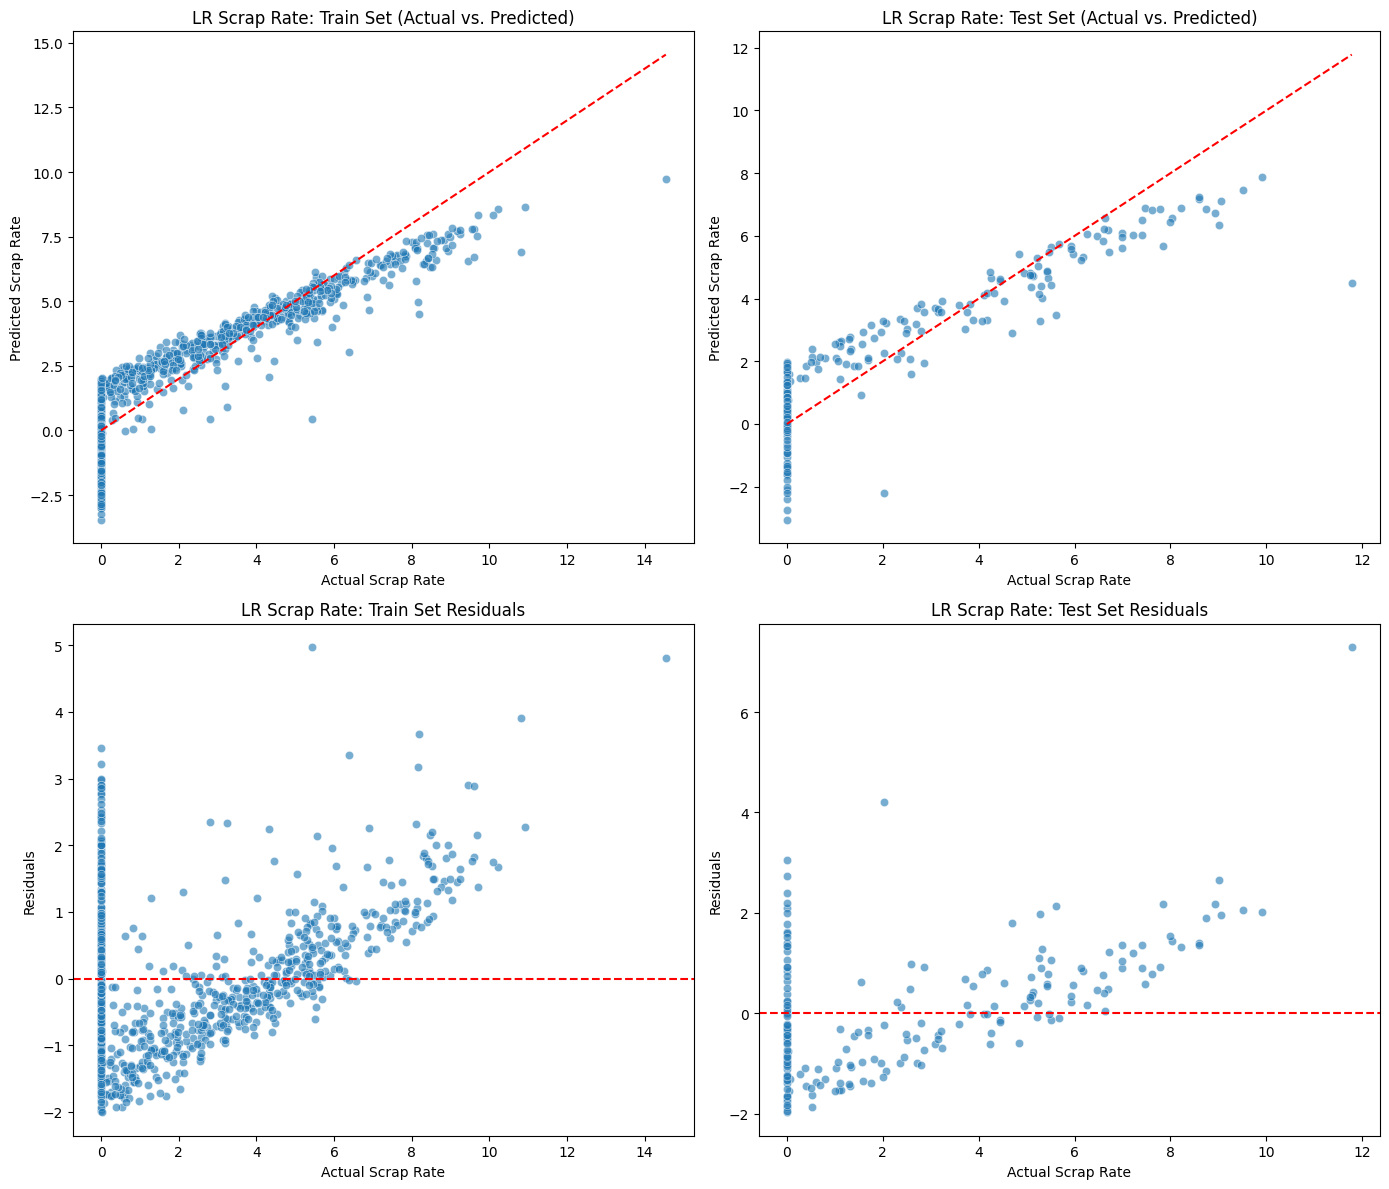

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# Visualizing Overfit Linear Regression for 'ScrapRate_Percentage'
# ----------------------------------------------------------------------------
# 1. Generate predictions for ScrapRate_Percentage
y_scrap_train_pred_lr = overfit_lr_scrap.predict(X_train_lr)
y_scrap_test_pred_lr  = overfit_lr_scrap.predict(X_test_lr)

# 2. Create a 2x2 grid of subplots for ScrapRate_Percentage
plt.figure(figsize=(14, 12))

# Train Set: Actual vs. Predicted
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_scrap_train, y=y_scrap_train_pred_lr, alpha=0.6)
plt.plot([y_scrap_train.min(), y_scrap_train.max()], [y_scrap_train.min(), y_scrap_train.max()], 'r--')
plt.title('LR Scrap Rate: Train Set (Actual vs. Predicted)')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Predicted Scrap Rate')

# Test Set: Actual vs. Predicted
plt.subplot(2, 2, 2)
sns.scatterplot(x=y_scrap_test, y=y_scrap_test_pred_lr, alpha=0.6)
plt.plot([y_scrap_test.min(), y_scrap_test.max()], [y_scrap_test.min(), y_scrap_test.max()], 'r--')
plt.title('LR Scrap Rate: Test Set (Actual vs. Predicted)')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Predicted Scrap Rate')

# Train Set: Residuals
plt.subplot(2, 2, 3)
sns.scatterplot(x=y_scrap_train, y=y_scrap_train - y_scrap_train_pred_lr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('LR Scrap Rate: Train Set Residuals')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Residuals')

# Test Set: Residuals
plt.subplot(2, 2, 4)
sns.scatterplot(x=y_scrap_test, y=y_scrap_test - y_scrap_test_pred_lr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('LR Scrap Rate: Test Set Residuals')
plt.xlabel('Actual Scrap Rate')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()